In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
x,y=make_regression(n_samples=100,n_features=1, n_informative=1,n_targets=1,noise=20,random_state=18)

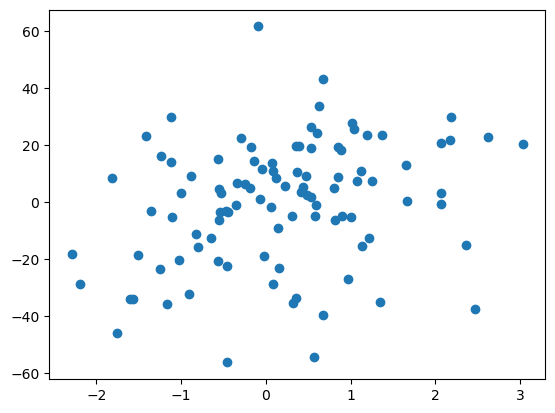

In [3]:
plt.scatter(x,y)

In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
lr=LinearRegression()

In [7]:
lr.fit(x_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[5.73493094]
-0.6607307379910642


In [8]:
y_pred=lr.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.024344364647461814

In [16]:
class GDRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,x,y):
        # calcualte the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*x.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*x.ravel() - self.b)*x.ravel())
            
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)
        
    def predict(self,x):
        return self.m * x + self.b
    

In [17]:
gd = GDRegressor(0.001,50)

In [18]:
gd.fit(x_train,y_train)

5.7621231356818985 -0.709338407358695


In [19]:
y_pred = gd.predict(x_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.024594967773763132